
# Customer Lifecycle & CRM Analytics

This notebook performs end-to-end CRM (Customer Relationship Management) analytics using the Online Retail dataset from UCI Machine Learning Repository.

## Business Objectives
- Identify high-value customers
- Measure retention and lifecycle behaviour
- Detect churn risk
- Estimate customer lifetime value
- Evaluate revenue concentration
- Provide actionable marketing recommendations

This workflow mirrors real CRM and marketing analytics pipelines used in industry.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from operator import attrgetter


## Load Dataset

In [2]:

df = pd.read_excel("Online Retail.xlsx")
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Data Cleaning

In [3]:

df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue'] = df['Quantity'] * df['UnitPrice']

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   Revenue      397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


## Reference Snapshot Date

In [4]:

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
snapshot_date


Timestamp('2011-12-10 12:50:00')

## RFM Calculation

In [5]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


## RFM Scoring (Quantiles)

In [6]:

rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm['RFM'] = rfm[['R_score','F_score','M_score']].astype(str).agg(''.join, axis=1)
rfm.head()


,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,115
12347.0,2,7,4310.00,5,5,5,555
12348.0,75,4,1797.24,2,4,4,244
12349.0,19,1,1757.55,4,1,4,414
12350.0,310,1,334.40,1,1,2,112


## K-Means Clustering for Customer Segmentation

In [7]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Prepare data for K-Means
X_rfm = rfm[['Recency', 'Frequency', 'Monetary']]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_rfm)

# Convert scaled data back to DataFrame for easier inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=X_rfm.columns, index=X_rfm.index)
display(X_scaled_df.head())

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.358668
12347.0,-0.905340,0.354417,0.250966
12348.0,-0.175360,-0.035340,-0.028596
12349.0,-0.735345,-0.425097,-0.033012
12350.0,2.174578,-0.425097,-0.191347


### Elbow Method to Determine Optimal Number of Clusters (K)

The Elbow method helps us find the optimal `k` (number of clusters) by looking for a 'bend' in the plot of inertia (sum of squared distances of samples to their closest cluster center) versus the number of clusters.

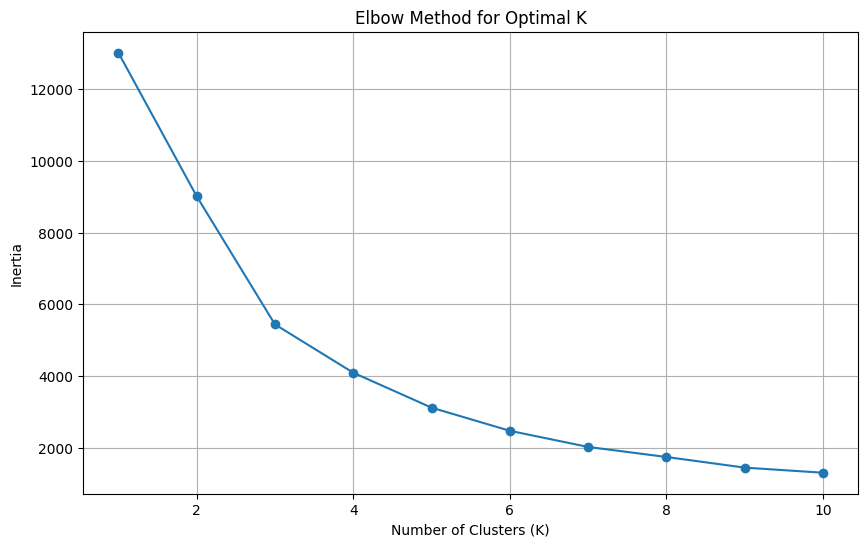

In [8]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

From the Elbow plot, choose an appropriate `k` (e.g., 3, 4, or 5 where the bend appears to be). Let's choose `k=4` for demonstration.

In [9]:
# Apply K-Means with the chosen K (e.g., K=4)
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
rfm['K_Cluster'] = kmeans.fit_predict(X_scaled)

display(rfm.head())

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM,K_Cluster
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,5,115,3
12347.0,2,7,4310.00,5,5,5,555,0
12348.0,75,4,1797.24,2,4,4,244,0
12349.0,19,1,1757.55,4,1,4,414,0
12350.0,310,1,334.40,1,1,2,112,1


### Analyze K-Means Clusters

Now, let's examine the characteristics of each cluster to understand what kind of customers fall into each group.

In [10]:
cluster_summary = rfm.reset_index().groupby('K_Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'Count'})

display(cluster_summary)

,Recency,Frequency,Monetary,Count
K_Cluster,,,,
0,43.702685,3.682711,1359.049284,3054
1,248.075914,1.552015,480.617480,1067
2,7.384615,82.538462,127338.313846,13
3,15.500000,22.333333,12709.090490,204


### Naming K-Means Clusters

Based on the `cluster_summary` table, we can interpret and name the K-Means clusters:

*   **Cluster 0: Regular/Mid-Value Customers**
    *   `Recency`: Moderate (43 days)
    *   `Frequency`: Moderate (3.68 times)
    *   `Monetary`: Moderate ($1359)
    *   `Count`: Largest segment (3054 customers)
    *   *Description*: This is our largest segment, consisting of customers who purchase somewhat regularly and spend a reasonable amount. They are a stable part of our customer base.

*   **Cluster 1: At-Risk/Churned Customers**
    *   `Recency`: High (248 days - haven't purchased in a long time)
    *   `Frequency`: Low (1.55 times)
    *   `Monetary`: Low ($480)
    *   `Count`: Second largest segment (1067 customers)
    *   *Description*: These customers have not purchased recently, have low purchasing frequency, and low monetary value. They are likely at risk of churning or have already churned.

*   **Cluster 2: VIP/High-Value Customers**
    *   `Recency`: Very Low (7 days - very recent purchase)
    *   `Frequency`: Very High (82.5 times)
    *   `Monetary`: Extremely High ($127,338)
    *   `Count`: Smallest segment (13 customers)
    *   *Description*: These are our most valuable customers, purchasing very frequently, spending significantly, and having made a recent purchase. They are crucial for our business.

*   **Cluster 3: Loyal & High-Spending Customers**
    *   `Recency`: Low (15.5 days)
    *   `Frequency`: High (22.3 times)
    *   `Monetary`: High ($12,709)
    *   `Count`: Moderate segment (204 customers)
    *   *Description*: These customers show strong loyalty and high spending, though not as extreme as the VIPs in Cluster 2. They are consistent and valuable customers.


### Visualizing RFM Distributions

Let's visualize the distribution of our Recency, Frequency, and Monetary values to get a better understanding of the customer base.

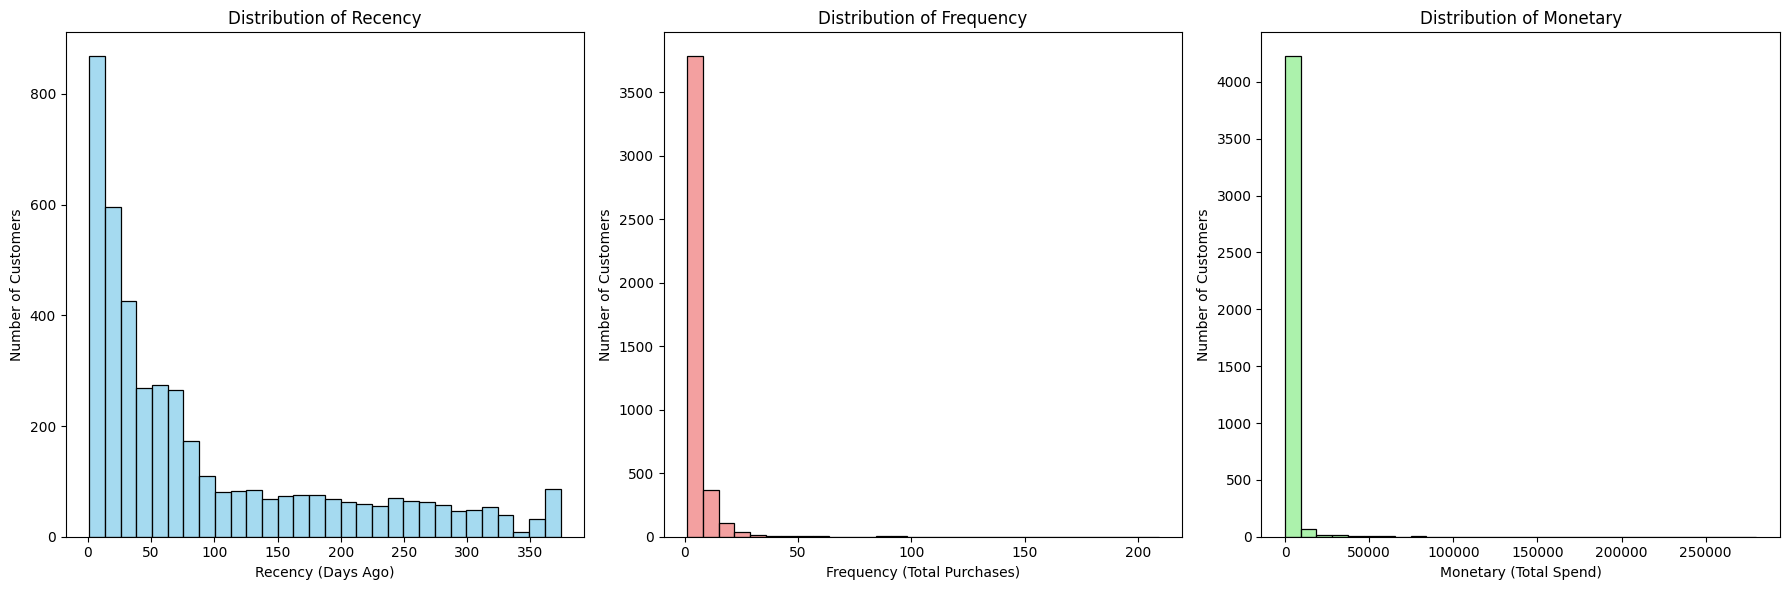

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.histplot(rfm['Recency'], bins=30, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Recency')
axes[0].set_xlabel('Recency (Days Ago)')
axes[0].set_ylabel('Number of Customers')

sns.histplot(rfm['Frequency'], bins=30, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Frequency')
axes[1].set_xlabel('Frequency (Total Purchases)')
axes[1].set_ylabel('Number of Customers')

sns.histplot(rfm['Monetary'], bins=30, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Monetary')
axes[2].set_xlabel('Monetary (Total Spend)')
axes[2].set_ylabel('Number of Customers')

plt.tight_layout()
plt.savefig("images/rfm_distribution.png")
plt.show()



These histograms reveal important characteristics of your customer base. The 'Recency' distribution shows a high concentration of customers who haven't made a purchase recently (higher Recency values), indicating a significant portion of potentially inactive or churned customers. Conversely, 'Frequency' and 'Monetary' distributions are heavily skewed towards lower values, suggesting that most customers make few purchases and spend relatively little. There are long tails in these distributions, indicating a small number of highly frequent and high-spending customers, which aligns with the Pareto principle (80/20 rule).

### Visualizing K-Means Cluster Profiles

Now, let's create a visual representation of the average Recency, Frequency, and Monetary values for each of the K-Means clusters. This will help to clearly differentiate the segments identified by the algorithm.

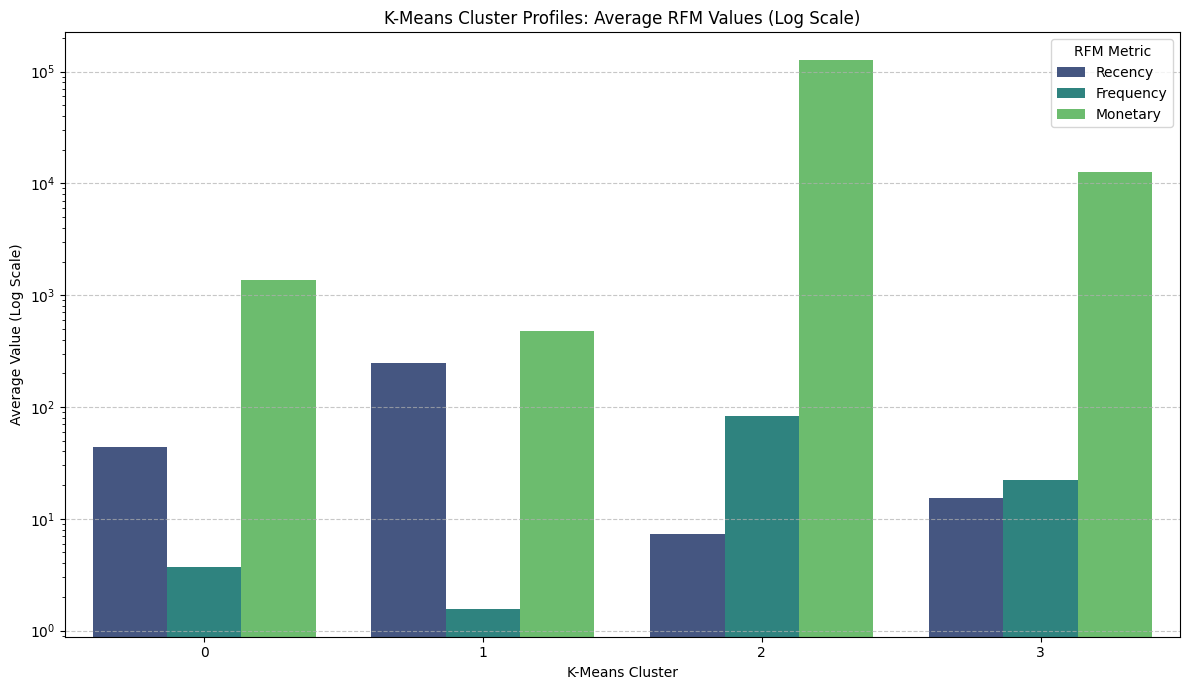

In [12]:
cluster_summary_melted = cluster_summary.drop('Count', axis=1).reset_index().melt(id_vars='K_Cluster', var_name='Metric', value_name='Average Value')

plt.figure(figsize=(12, 7))
sns.barplot(x='K_Cluster', y='Average Value', hue='Metric', data=cluster_summary_melted, palette='viridis')
plt.title('K-Means Cluster Profiles: Average RFM Values (Log Scale)')
plt.xlabel('K-Means Cluster')
plt.ylabel('Average Value (Log Scale)')
plt.yscale('log') # Apply logarithmic scale to the y-axis
plt.legend(title='RFM Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("images/cluster_plot.png")
plt.show()



The K-Means cluster profiles, now visualized with a logarithmic scale on the y-axis, provide a clearer distinction between the segments. This scaling effectively compresses the large monetary values (like those in Cluster 2) and allows for better comparison of the relatively smaller differences in Recency and Frequency across all clusters. We can more easily see the 'At-Risk' customers (Cluster 1) with high Recency, and the 'VIP' (Cluster 2) and 'Loyal & High-Spending' (Cluster 3) customers with very low Recency and high Frequency/Monetary values. The 'Regular/Mid-Value' customers (Cluster 0) occupy the middle ground, indicating consistent but not extreme behavior across all RFM metrics.

### K-Means vs. Rule-Based Segmentation: Key Differences

**1. Rule-Based Segmentation (Your previous method)**
*   **How it works:** You define explicit rules (e.g., 'Champions' are customers with R >= 4, F >= 4, M >= 4). These rules are often based on business intuition, domain expertise, or pre-defined benchmarks.
*   **Pros:**
    *   **Interpretability:** Segments are very easy to understand and explain, as the criteria are clear.
    *   **Direct Control:** You have full control over the segment definitions, allowing you to align them perfectly with existing business strategies or marketing campaigns.
    *   **Stability:** Segment definitions remain consistent over time, as long as your business rules don't change.
*   **Cons:**
    *   **Arbitrary Thresholds:** The choice of thresholds (e.g., what constitutes 'high' recency) can be subjective and might not reflect natural groupings in the data.
    *   **Less Data-Driven:** May miss subtle patterns or natural clusters that don't perfectly align with your defined rules.
    *   **Scalability:** Defining rules for many different segments or dimensions can become complex.

**2. K-Means Clustering (The new method)**
*   **How it works:** An unsupervised machine learning algorithm that automatically groups data points into `k` clusters, where `k` is a pre-defined number. It minimizes the within-cluster variance, meaning data points within a cluster are similar to each other, and different from points in other clusters.
*   **Pros:**
    *   **Data-Driven:** Discovers natural groupings in the data that might not be obvious through manual rule definition.
    *   **Objectivity:** Reduces subjectivity in segment definition as it's based on mathematical optimization.
    *   **Efficiency:** Can process large datasets and identify complex patterns more efficiently than manual rule creation.
*   **Cons:**
    *   **Interpretability:** Clusters can sometimes be harder to interpret, requiring post-hoc analysis (like the `cluster_summary` we performed) to understand their characteristics.
    *   **Choice of `k`:** Determining the optimal number of clusters (`k`) can be subjective (e.g., using the elbow method, which can have ambiguous 'elbows').
    *   **Sensitive to Scaling:** Requires features to be scaled (as you did with `StandardScaler`) otherwise features with larger magnitudes can disproportionately influence the clustering.



## Industry Standard Customer Segmentation

In [13]:

def segment_customer(row):
    r = int(row['R_score'])
    f = int(row['F_score'])
    m = int(row['M_score'])

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif f >= 4:
        return 'Loyal Customers'
    elif r >= 4:
        return 'Recent Customers'
    elif r <= 2 and f <= 2:
        return 'At Risk'
    else:
        return 'Potential'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
rfm['Segment'].value_counts()


,count
Segment,
At Risk,1065
Champions,962
Potential,905
Loyal Customers,773
Recent Customers,633


## Revenue Contribution by Segment

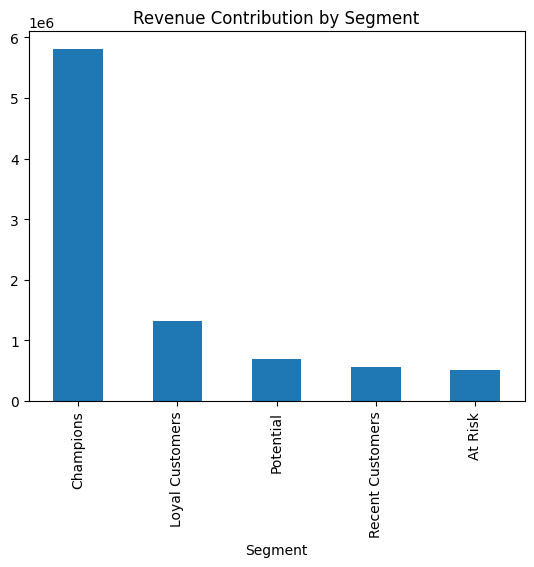

,Monetary
Segment,
Champions,5809341.070
Loyal Customers,1327476.791
Potential,694523.261
Recent Customers,560658.210
At Risk,519408.572


<Figure size 640x480 with 0 Axes>

In [14]:

segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
segment_revenue.plot(kind='bar')
plt.title("Revenue Contribution by Segment")
plt.show()
plt.savefig("images/revenue_contribution.png")

segment_revenue




This bar chart clearly illustrates the disproportionate contribution of the 'Champions' segment to the overall revenue. 'Champions' (the top segment by RFM score) generate the vast majority of the company's monetary value, far outstripping all other segments combined. 'Loyal Customers' contribute the second-highest amount, followed by 'Potential', 'Recent Customers', and 'At Risk' customers. This highlights the critical importance of retaining and nurturing the 'Champions' and 'Loyal Customers' segments, while also identifying strategies to move customers from lower-value segments into higher-value ones.

## Cohort Analysis

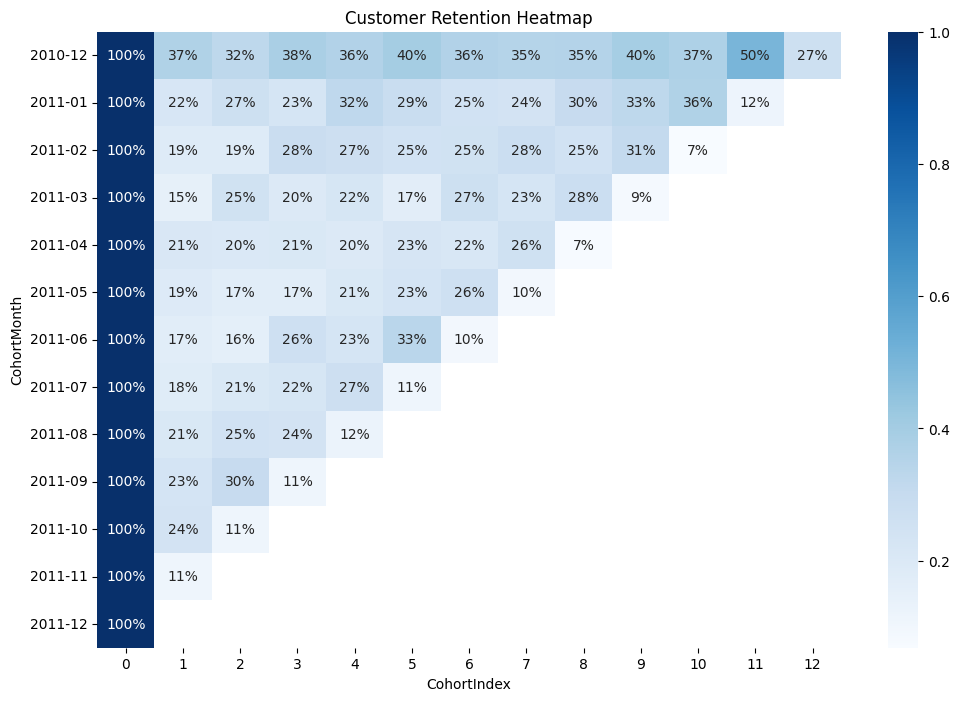

In [15]:
import os

df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')
df['CohortIndex'] = (df['InvoiceMonth'] - df['CohortMonth']).apply(attrgetter('n'))

cohort_data = df.groupby(['CohortMonth','CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')
cohort_size = cohort_counts.iloc[:,0]
retention = cohort_counts.divide(cohort_size, axis=0)

plt.figure(figsize=(12,8))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues")
plt.title("Customer Retention Heatmap")

# Create the 'images' directory if it doesn't exist
if not os.path.exists('images'):
    os.makedirs('images')

plt.savefig("images/cohort_heatmap.png")
plt.show()



This heatmap visually represents customer retention rates over time, broken down by acquisition cohort. Each row represents a cohort (customers acquired in a specific month), and each column represents the 'CohortIndex' (months since acquisition). The diagonal values (CohortIndex 0) always show 100% retention (as it's the month of acquisition). As you move across a row, the color intensity indicates the percentage of customers from that cohort who are still active. A clear trend of decreasing retention over time (moving right across a row) is expected. The heatmap helps identify which cohorts have higher or lower retention rates compared to others, and can reveal seasonal patterns or the impact of specific marketing initiatives on customer loyalty. For example, a consistently lighter shade in later columns for certain cohorts might indicate an issue with product or service quality for customers acquired during those periods.

## Customer Lifetime Value

In [16]:

avg_order_value = df.groupby('CustomerID')['Revenue'].mean()
purchase_freq = df.groupby('CustomerID')['InvoiceNo'].nunique()
lifespan_days = df.groupby('CustomerID')['InvoiceDate'].agg(lambda x: (x.max()-x.min()).days)
lifespan_months = lifespan_days / 30

clv = avg_order_value * purchase_freq * lifespan_months
rfm['CLV'] = clv.fillna(0)
rfm[['CLV']].head()


,CLV
CustomerID,
12346.0,0.000000
12347.0,2016.858974
12348.0,2179.878194
12349.0,0.000000
12350.0,0.000000


## Churn Identification (No purchase in 90 days)

In [17]:

rfm['Churn'] = np.where(rfm['Recency'] > 90, 1, 0)
churn_rate = rfm['Churn'].mean()
churn_rate


np.float64(0.33402489626556015)

## Churn Prediction Model

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X = rfm[['Frequency','Monetary']] # Removed 'Recency' to prevent data leakage
y = rfm['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.78      0.80      0.79       865
           1       0.58      0.55      0.56       437

    accuracy                           0.72      1302
   macro avg       0.68      0.67      0.68      1302
weighted avg       0.71      0.72      0.71      1302



### Interpretation of Churn Prediction Model Metrics

After correcting for data leakage, the churn prediction model yields more realistic results. For the churn class (labeled as '1'), the model achieves a precision of 0.58, meaning 58% of customers predicted to churn actually do. The recall for the churn class is 0.55, indicating that the model successfully identifies 55% of all actual churning customers. The F1-score of 0.56 provides a balanced measure of the model's performance for churn. While these scores are lower than for the non-churn class (labeled '0'), which has higher precision and recall, they are more indicative of the real challenge in predicting customer churn and provide a solid baseline for future improvements.

## ROC Curve for Churn Prediction

The Receiver Operating Characteristic (ROC) curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. It plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold settings. The Area Under the Curve (AUC) provides a single number summarizing the model's performance across all possible classification thresholds.

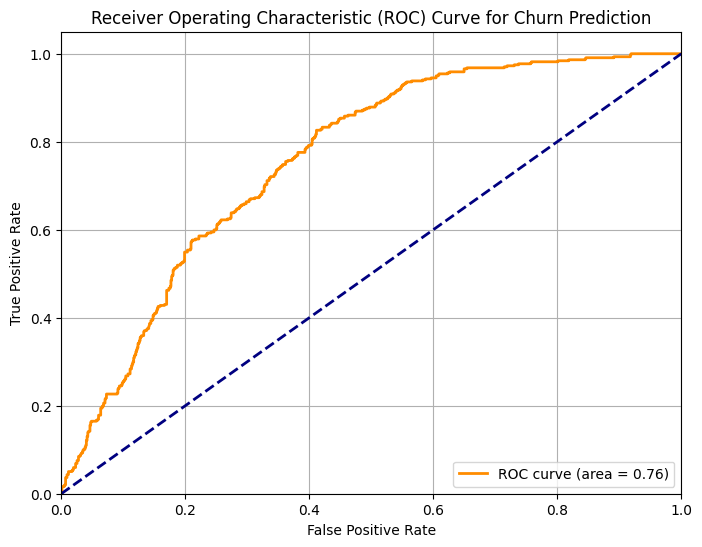

In [19]:
from sklearn.metrics import RocCurveDisplay, roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (churn)
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate FPR, TPR, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Churn Prediction')
plt.legend(loc="lower right")
plt.grid(True)

# Create the 'images' directory if it doesn't exist
if not os.path.exists('images'):
    os.makedirs('images')

plt.savefig("images/roc_curve.png")
plt.show()

The ROC curve visually represents the trade-off between the true positive rate and the false positive rate for our churn prediction model. The closer the curve is to the top-left corner, the better the model's performance. The AUC (Area Under the Curve) score of **{roc_auc:.2f}** indicates the probability that the model will rank a randomly chosen positive instance higher than a randomly chosen negative instance. An AUC of 0.5 suggests no discrimination (like random guessing), while an AUC of 1.0 indicates a perfect classifier. Our model's AUC value suggests it has reasonable discriminatory power for predicting churn.

## Segment Summary Table

In [20]:

summary = rfm.groupby('Segment').agg({
    'Monetary':'mean',
    'Frequency':'mean',
    'Recency':'mean',
    'CLV':'mean',
    'Churn':'mean'
})
summary


,Monetary,Frequency,Recency,CLV,Churn
Segment,,,,,
At Risk,487.707579,1.101408,217.897653,26.930513,0.879812
Champions,6038.816081,11.080042,12.861746,5737.570429,0.000000
Loyal Customers,1717.305034,5.025873,73.379043,1383.097467,0.263907
Potential,767.429018,1.861878,98.600000,229.575728,0.340331
Recent Customers,885.715972,1.785150,17.431280,1388.236398,0.000000


## Strategic CRM Recommendations (Based on Rule-Based Segments)

Based on the RFM scores and the summary table, here are refined recommendations for your existing segments:

### Champions (High-Value, Loyal, Recent - Low Churn)
*   **Goal:** Retain, reward, and leverage for advocacy.
*   **Actions:**
    *   **Exclusive VIP Programs:** Offer access to premium services, dedicated support, or early product releases.
    *   **Referral Incentives:** Encourage them to bring in new customers with attractive rewards for both parties.
    *   **Personalized Surveys/Feedback:** Engage them in product development or strategic decisions, making them feel valued.
    *   **Personalized High-Value Offers:** Introduce them to premium product lines or complementary services.

### Loyal Customers (Frequent, Moderate Recency - Moderate Churn Risk)
*   **Goal:** Increase engagement, upsell, cross-sell, and proactively prevent churn.
*   **Actions:**
    *   **Tiered Loyalty Programs:** Provide escalating benefits to encourage higher spending and frequency, with clear paths to 'Champion' status.
    *   **Proactive Retention:** Monitor their activity and send personalized offers or content if engagement starts to drop.
    *   **Personalized Recommendations:** Use their purchase history to suggest relevant upsells or cross-sells, perhaps with a small, exclusive discount.
    *   **Community Building:** Invite them to exclusive groups or forums to foster a sense of belonging and gather insights.

### At Risk Customers (Low Frequency, High Recency - High Churn Risk)
*   **Goal:** Win-back, understand reasons for disengagement, and prevent churn.
*   **Actions:**
    *   **Compelling Win-Back Campaigns:** Offer significant, time-limited discounts or special bundles on their preferred products.
    *   **Re-engagement Surveys:** Reach out to understand why they became inactive, offering a small incentive for participation.
    *   **Highlight New Products/Features:** Showcase recent additions or improvements that might rekindle their interest.
    *   **Easy Returns/Flexible Policies:** Address potential pain points or reasons for their disengagement by offering customer-friendly policies.

### Potential Customers (Low Frequency, Moderate Recency - Moderate Churn Risk)
*   **Goal:** Drive initial engagement, encourage repeat purchases, and educate.
*   **Actions:**
    *   **Second Purchase Incentives:** Offer a small discount or free shipping on their next purchase within a specific timeframe.
    *   **Product Education:** Send targeted content (e.g., how-to guides, usage tips, related product ideas) based on their first purchase or browsing history.
    *   **Personalized Welcome Series:** Onboard them effectively with information about benefits, customer support, and value propositions.
    *   **Showcase Bestsellers/Relevant Categories:** Introduce them to other popular products or categories that align with their interests.

### Recent Customers (High Recency, Low Frequency - Low Churn)
*   **Goal:** Nurture, convert to loyal, and encourage second purchase.
*   **Actions:**
    *   **Onboarding & Welcome Journey:** Provide resources and support to ensure a positive initial experience.
    *   **Encourage Next Purchase:** Offer a small, personalized incentive or recommendation for their second purchase.
    *   **Feedback on First Purchase:** Gather insights on their initial experience to improve services and product offerings.
    *   **Introduce Loyalty Program:** Educate them about the benefits of continued engagement early on.

## Strategic CRM Recommendations (Based on K-Means Clusters)

These recommendations are tailored to the naturally occurring customer segments identified by K-Means clustering:

### Cluster 0: Regular/Mid-Value Customers (Largest Segment, Moderate RFM)
*   **Goal:** Increase purchase frequency and monetary value, move them towards 'Loyal' or 'High-Spending' status.
*   **Actions:**
    *   **Subscription or Membership Offers:** Encourage recurring purchases with convenient subscription options or exclusive memberships.
    *   **Personalized Product Discovery:** Recommend products based on their past purchases and browsing behavior to expand their interests.
    *   **Loyalty Points Programs:** Reward consistent purchasing with points that can be redeemed for discounts or exclusive items.
    *   **Targeted Promotions:** Offer discounts or bundles on items that complement their purchasing habits.

### Cluster 1: At-Risk/Churned Customers (High Recency, Low RFM)
*   **Goal:** Re-engage, understand reasons for inactivity, and win-back lost revenue.
*   **Actions:**
    *   **Aggressive Win-Back Campaigns:** Provide substantial, time-sensitive offers (e.g., high-percentage discounts, exclusive product access) to entice them back.
    *   **Customer Feedback Surveys:** Conduct short surveys to understand their reasons for disengagement and identify areas for improvement.
    *   **Showcase Value Proposition:** Remind them of the unique benefits or new features of your products/services.
    *   **Personalized 'We Miss You' Content:** Send tailored recommendations or content based on their past interactions.

### Cluster 2: VIP/High-Value Customers (Extremely High RFM, Very Small Segment)
*   **Goal:** Maximize retention, cultivate brand loyalty, and encourage advocacy.
*   **Actions:**
    *   **White-Glove Service:** Offer a dedicated account manager or priority customer support channel.
    *   **Exclusive Event Invitations:** Invite them to private sales, product launches, or company events.
    *   **Early Access Programs:** Grant them first access to new products, features, or beta testing opportunities.
    *   **Personalized Thank-You Gifts:** Send bespoke gifts or experiences to show appreciation for their significant contribution.

### Cluster 3: Loyal & High-Spending Customers (Low Recency, High Frequency & Monetary)
*   **Goal:** Elevate their loyalty, foster continued high spending, and encourage advocacy.
*   **Actions:**
    *   **Premium Loyalty Tiers:** Offer a distinct loyalty tier with enhanced benefits to acknowledge their high value and encourage progression towards VIP status.
    *   **Personalized Curated Collections:** Send them curated product selections or exclusive bundles based on their sophisticated tastes.
    *   **Feedback & Influence:** Involve them in product feedback sessions or provide opportunities for them to influence future offerings.
    *   **Special Birthday/Anniversary Offers:** Recognize and reward their loyalty with meaningful, personalized celebratory offers.

## Conclusion

This notebook has demonstrated an end-to-end CRM analytics workflow, from data loading and cleaning to advanced customer segmentation using RFM and K-Means clustering, churn prediction, and customer lifetime value estimation. The insights gained from these analyses provide a strong foundation for developing targeted marketing strategies and improving customer relationships.